In [1]:
import torch
import time
import warnings
import os
from tqdm import tqdm
from torch.utils.tensorboard import SummaryWriter
from numba.core.errors import NumbaWarning

from device import setup_device
from datasets.utk_dataset import UTKFaceDataset
from datasets.loading import get_full_loader, get_data_loaders
from datasets.extraction import extract_embeddings
from model.encoder import Encoder
from model.loading import load_model
from loss import *
from train.train_encoder import *
from analysis.visualization import *
from analysis.extraction import *
from setup.optimizer_setup import setup_optimizer
from setup.scheduler_setup import setup_scheduler
from setup.monitor_setup import setup_monitor
from setup.model_setup import setup_encoder

In [2]:
warnings.filterwarnings("ignore", message=".*force_all_finite.*")
warnings.filterwarnings("ignore", category=NumbaWarning)
warnings.filterwarnings("ignore", message=".*verbose parameter is deprecated.*")
warnings.filterwarnings("ignore", message=".*epoch parameter in `scheduler.step.*")

In [3]:
verbose=True

# Model parameters
backbone_model = 'resnet50'
pretrained = True

# Training parameters
test_dir = './outputs/current/initial_test'
best_model_file = os.path.join(test_dir, 'best_model.pth')
key_metric = 'kendall'
mode = 'max'
analysis_dir = os.path.join(test_dir, 'analysis')
learning_rate = 1e-3
data_folder = './data/utkface/UTKFace'
augmentations = 'crop,flip,color,grayscale'
batch_size = 256
train_size = 0.8

In [4]:
# Setup device
device, data_parallel = setup_device(use_gpu_1_only=False, verbose=verbose)

# Setup model
model = setup_encoder(backbone_model, data_parallel, pretrained, device)

# Setup monitor
writer = SummaryWriter(log_dir=test_dir)
monitor_config = {
    'key_metric': 'kendall',
    'mode': 'max',

    'save_best_model': True,
    'best_model_file': best_model_file,

    'save_intermediate_models': True,
    'analysis_dir': analysis_dir,

    'use_early_stopping': True,
    'patience': 10,
    'delta': 1e-4,

    'write_to_tensorboard': True,
    'writer': writer
}
monitor = setup_monitor(
    monitor_config,
    verbose=verbose
)

# Setup data loaders
train_loader, val_loader = get_data_loaders(
    data_folder, augmentations,
    batch_size=batch_size, train_size=train_size
)

# Setup optimizer and scheduler
optimizer = setup_optimizer('adam', model, learning_rate)
scheduler = setup_scheduler('steplr', optimizer, step_size=10, gamma=0.1)

# Training config
train_config = {
    'device': device,
    'train_loader': train_loader,
    'val_loader': val_loader,
    'optimizer': optimizer,
    'scheduler': scheduler,
    'temperature': 0.5,
    'train_config': {
        'model': model,
        'num_epochs': 3,
        'monitor': monitor,
        'metrics': [
            "val_loss",
            "embedding_norm",
            "embedding_variance",
            "knn_accuracy",
            "spearman",
            "kendall",
            "grad_norm",
            "lr"
        ]
    }
}

[18:58:51] [INFO] ✅ CUDA is available: 2 GPU(s) visible
[18:58:51] [INFO] 🚀 Wrapping model in DataParallel over 2 GPUs
[18:58:51] [INFO] Enabled monitors: ['LoggingMonitor', 'OptimumMonitor', 'SaveModelMonitor', 'EarlyStoppingMonitor', 'TensorboardMonitor']


In [5]:
# Training cell
start_time = time.time()
train_encoder(train_config, verbose=verbose)
end_time = time.time()
print_verbose(f"Training completed in: {end_time - start_time:.2f} seconds", verbose)

[18:58:51] [INFO] Configuration check passed: 7 keys found.
[18:58:51] [INFO] Configuration check passed: 9 keys found.
[18:58:51] [INFO] Training on device: cuda


Extracting Embeddings: 100%|██████████████████████████████| 19/19 [ 6.45batch/s]


[18:59:55] [INFO] [Epoch 0] kendall: 0.4849 (max)
[18:59:55] [INFO] ✅ New best kendall: 0.4849 (max)


Extracting Embeddings: 100%|██████████████████████████████| 19/19 [ 6.37batch/s]


[19:00:58] [INFO] [Epoch 1] kendall: 0.5317 (max)
[19:00:59] [INFO] ✅ New best kendall: 0.5317 (max)


Extracting Embeddings: 100%|██████████████████████████████| 19/19 [ 6.36batch/s]


[19:02:02] [INFO] [Epoch 2] kendall: 0.5497 (max)
[19:02:03] [INFO] ✅ New best kendall: 0.5497 (max)
[19:02:03] [INFO] Training complete!
[19:02:03] [INFO] Training completed in: 191.44 seconds


In [6]:
# Embedding extraction for visualization
embeddings, labels = extract_best_encoder_embeddings(model, best_model_file, data_folder, device, verbose)
embeddings_list, labels_list = extract_encoder_embeddings_over_epochs(
    model,
    analysis_dir,
    data_folder,
    device,
    verbose
)

# Parameters for visualization
vis_args = {
    'embeddings': embeddings,
    'labels': labels,
    'figsize': (6, 6),
    'figssize': (3, 3),
    'n': 1500,
    'title': 'Projection',
    'embeddings_list': embeddings_list,
    'labels_list': labels_list
}

# Visualizations to run
selected = ['umap', 'similarity_matrix', 'umap_all']

[19:02:03] [INFO] Loaded model from ./outputs/current/initial_test/best_model.pth


Extracting Embeddings: 100%|████████████████████████████| 371/371 [19.51batch/s]


[19:02:22] [INFO] Shape of embeddings: (23708, 128)
[19:02:22] [INFO] Memory usage of embeddings: 11.58 MB
[19:02:22] [INFO] Loaded model from ./outputs/current/initial_test/analysis/model_epoch_000.pth


Extracting Embeddings: 100%|████████████████████████████| 371/371 [19.53batch/s]


[19:02:41] [INFO] Loaded model from ./outputs/current/initial_test/analysis/model_epoch_001.pth


Extracting Embeddings: 100%|████████████████████████████| 371/371 [19.68batch/s]


[19:03:00] [INFO] Loaded model from ./outputs/current/initial_test/analysis/model_epoch_002.pth


Extracting Embeddings: 100%|████████████████████████████| 371/371 [19.74batch/s]


[19:03:36] [INFO] [visualize] Running: umap
[19:03:58] [INFO] [plot_umap] embeddings: (23708, 128), labels: (23708,)


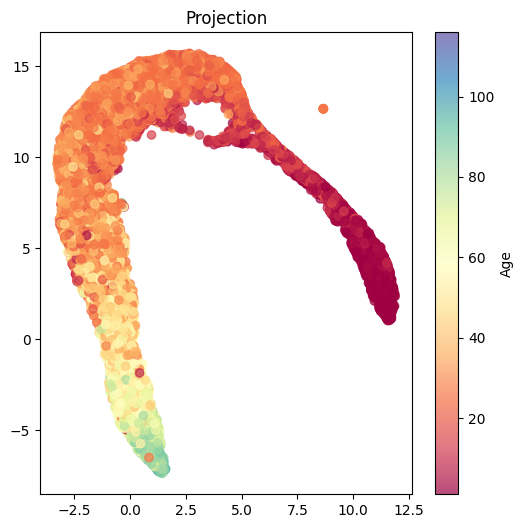

[19:03:59] [INFO] [visualize] Running: similarity_matrix
[19:03:59] [INFO] [plot_similarity_matrix] embeddings: torch.Size([1500, 128]), labels: torch.Size([1500])


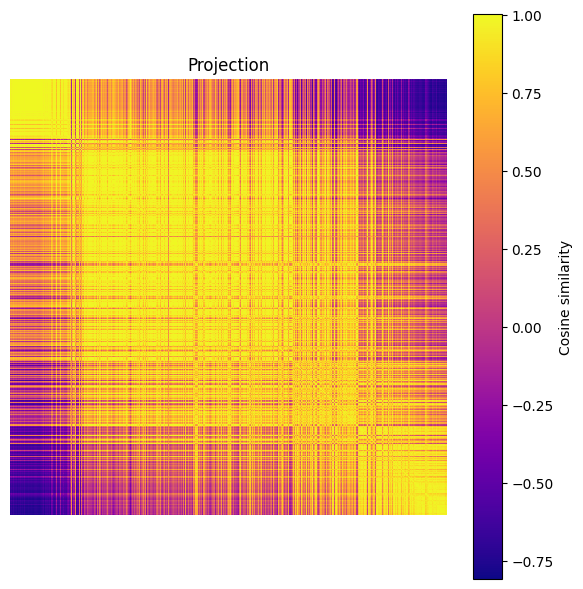

[19:03:59] [INFO] [visualize] Running: umap_all
[19:04:07] [INFO] [plot_umap_all_epochs_grid] Epoch 0: (23708, 128), (23708,)
[19:04:15] [INFO] [plot_umap_all_epochs_grid] Epoch 1: (23708, 128), (23708,)
[19:04:23] [INFO] [plot_umap_all_epochs_grid] Epoch 2: (23708, 128), (23708,)


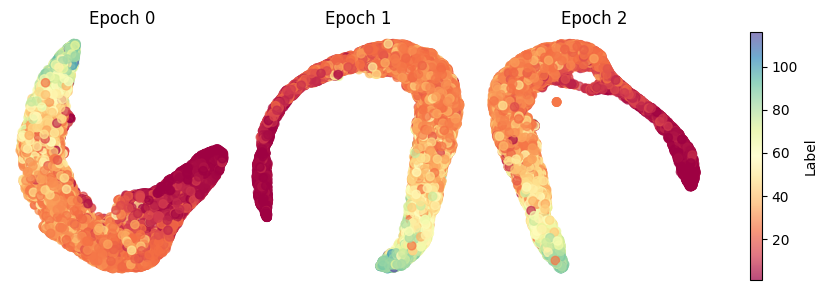

[19:04:24] [INFO] Visualization computed in: 47.50 seconds


In [8]:
# Analysis cell
start_time = time.time()
visualize(selected, vis_args, verbose=verbose)
end_time = time.time()

print_verbose(f"Visualization computed in: {end_time - start_time:.2f} seconds", verbose)